In [1]:
file_read = "004_fit_MPAA"
file_write = "005_RMSE_MPAA"

In [2]:
import polars as pl

df_train_val_preds = pl.read_parquet(f"{file_read}_train_val_preds.parquet")
df_test_preds = pl.read_parquet(f"{file_read}_test_preds.parquet")
df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [3]:
column_target = "beta_alpha"
column_pred = f"{column_target}_pred"

In [4]:
df_train_val_rmse = (
    df_train_val_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [5]:
df_train_val_rmse

n_features,beta_alpha_rmse
i32,f64
86,0.196702
85,0.196702
84,0.196702
83,0.196702
82,0.196702
…,…
9,0.206202
8,0.210229
7,0.213874


In [6]:
df_train_val_rmse_min = df_train_val_rmse.filter(
    pl.col(f"{column_target}_rmse") == pl.col(f"{column_target}_rmse").min()
)

In [7]:
df_train_val_rmse_min

n_features,beta_alpha_rmse
i32,f64
86,0.196702
85,0.196702
84,0.196702
83,0.196702


In [8]:
n_features_min = df_train_val_rmse_min["n_features"][-1]

In [9]:
df_test_rmse = (
    df_test_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [10]:
df_test_rmse

n_features,beta_alpha_rmse
i32,f64
86,0.4816
85,0.4816
84,0.4816
83,0.4816
82,0.48161
…,…
9,0.70745
8,0.709756
7,0.711997


In [11]:
df_test_rmse_min = df_test_rmse.filter(pl.col("n_features") == n_features_min)

In [12]:
df_test_rmse_min

n_features,beta_alpha_rmse
i32,f64
83,0.4816


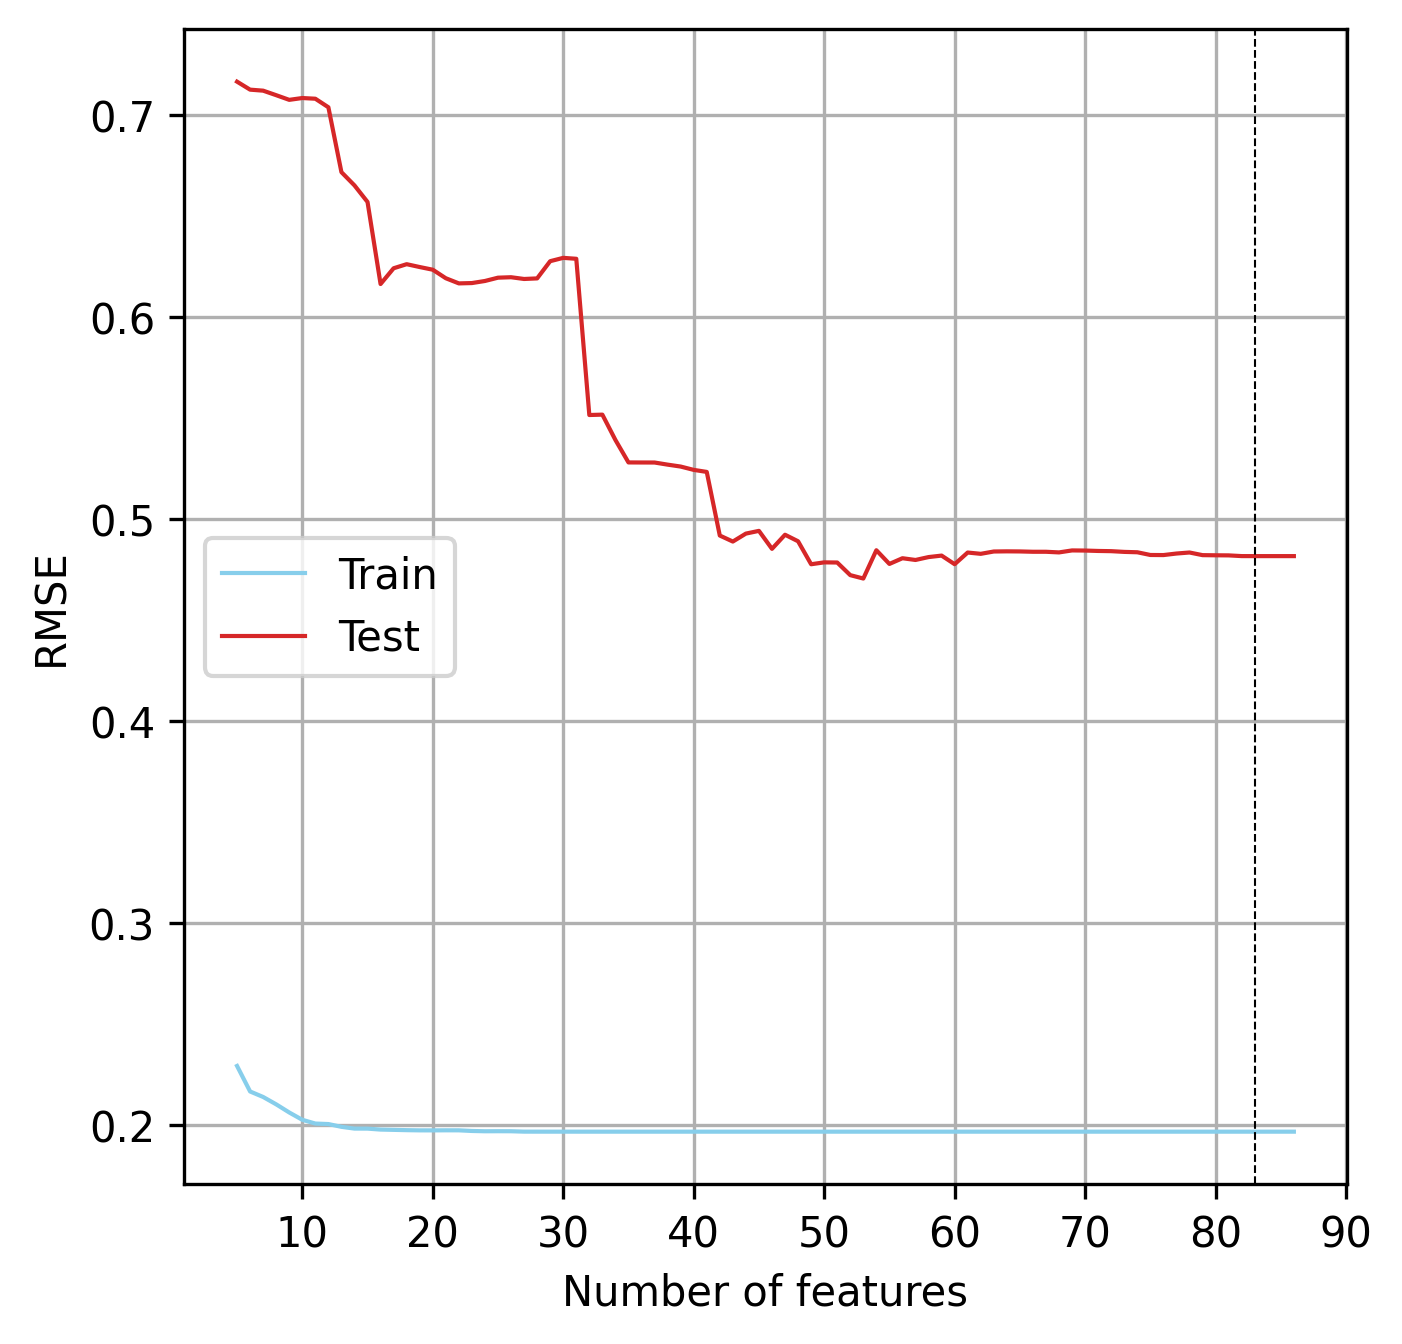

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    df_train_val_rmse["n_features"],
    df_train_val_rmse[f"{column_target}_rmse"],
    c="skyblue",
    label="Train",
    lw=1
)
ax.plot(
    df_test_rmse["n_features"],
    df_test_rmse[f"{column_target}_rmse"],
    c="tab:red",
    label="Test",
    lw=1
)
ax.axvline(
    n_features_min,
    c="black",
    lw=0.5,
    ls="--"
)

ax.set_xlabel("Number of features")
ax.set_ylabel("RMSE")

ax.grid()
ax.legend()

plt.savefig(
    f"{file_write}_plot.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [14]:
df_train_val_min = df_train_val_preds.filter(pl.col("n_features") == n_features_min)

In [15]:
df_train_val_min

backbone_test,n_features,backbone,pyridone,beta_alpha,beta_alpha_pred
i32,i32,i64,i64,f64,f64
0,83,1,0,2.556494,2.658247
0,83,2,0,2.635717,2.664151
0,83,3,0,2.576968,2.559233
0,83,4,0,2.582272,2.573596
0,83,5,0,3.727095,3.772967
…,…,…,…,…,…
20,83,2,12,2.69912,2.634414
20,83,3,12,2.554692,2.529485
20,83,4,12,2.587168,2.543871


In [16]:
df_test_min = df_test_preds.filter(pl.col("n_features") == n_features_min)

In [17]:
df_test_min

backbone_test,n_features,pyridone,beta_alpha,beta_alpha_pred
i32,i32,i64,f64,f64
0,83,0,2.524862,2.649531
0,83,1,2.928763,3.130031
0,83,2,3.171724,3.044495
0,83,3,2.984961,2.955783
0,83,4,2.78847,2.806997
…,…,…,…,…
20,83,8,1.808185,2.573939
20,83,9,1.83243,2.602016
20,83,10,1.843979,2.52599


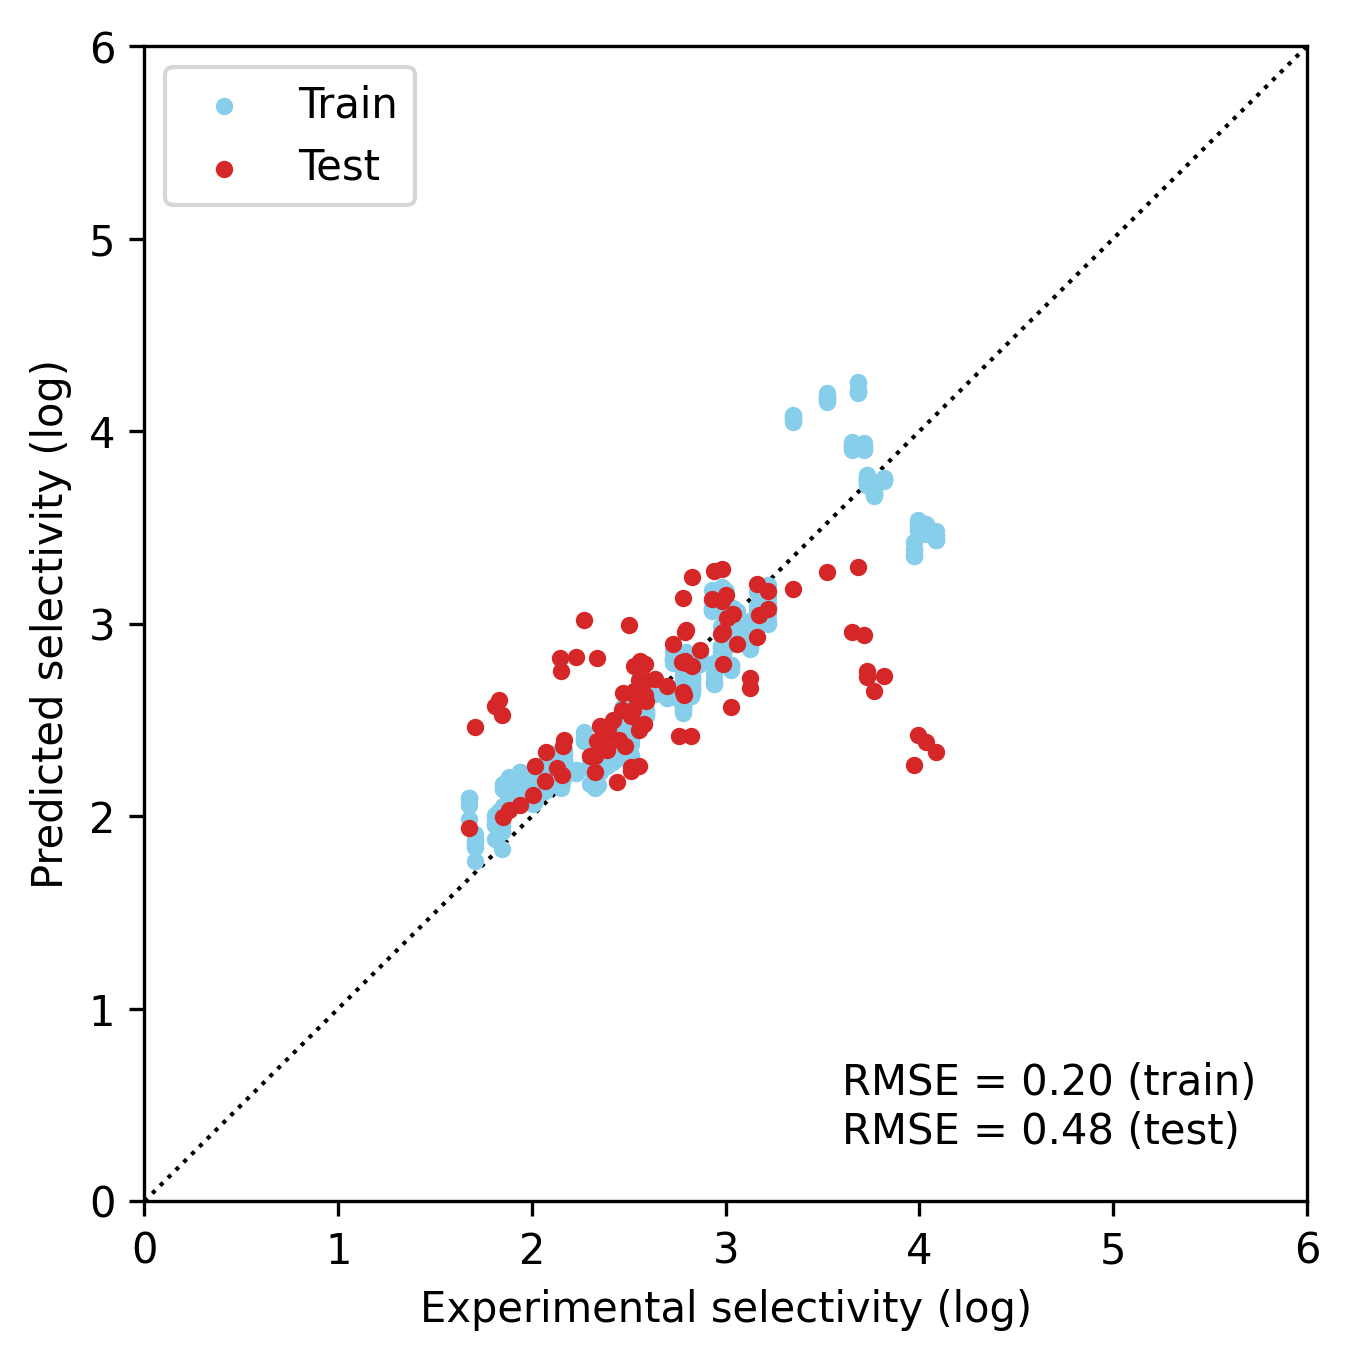

In [18]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    [0, 100],
    [0, 100],
    c="black",
    linestyle="dotted",
    lw=1,
    zorder=0
)
ax.scatter(
    df_train_val_min[column_target],
    df_train_val_min[column_pred],
    c="skyblue",
    label="Train",
    s=10,
    zorder=1
)
ax.scatter(
    df_test_min[column_target],
    df_test_min[column_pred],
    c="tab:red",
    label="Test",
    s=10,
    zorder=2
)

ax.set_xlabel("Experimental selectivity (log)")
ax.set_ylabel("Predicted selectivity (log)")
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)

ax.legend()
ax.text(
    0.60, 0.05,
    f"RMSE = {df_train_val_rmse_min[f'{column_target}_rmse'][0]:1.2f} (train)\n"
    f"RMSE = {df_test_rmse_min[f'{column_target}_rmse'][0]:1.2f} (test)",
    transform=ax.transAxes
)

plt.savefig(
    f"{file_write}_scatter_all.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [19]:
column_group = "backbone"

In [20]:
groups_test = df_test_preds[f"{column_group}_test"].unique(maintain_order=True)

In [21]:
groups_test

backbone_test
i32
0
1
2
3
4
5
19
20


In [22]:
df_train_val_min

backbone_test,n_features,backbone,pyridone,beta_alpha,beta_alpha_pred
i32,i32,i64,i64,f64,f64
0,83,1,0,2.556494,2.658247
0,83,2,0,2.635717,2.664151
0,83,3,0,2.576968,2.559233
0,83,4,0,2.582272,2.573596
0,83,5,0,3.727095,3.772967
…,…,…,…,…,…
20,83,2,12,2.69912,2.634414
20,83,3,12,2.554692,2.529485
20,83,4,12,2.587168,2.543871


In [23]:
df_train_val_min_rmse = (
    df_train_val_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [24]:
df_train_val_min_rmse

backbone_test,beta_alpha_rmse
i32,f64
0,0.209985
1,0.210296
2,0.211063
3,0.208262
4,0.208028
5,0.102448
19,0.193187
20,0.205432


In [25]:
df_test_min_rmse = (
    df_test_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [26]:
df_test_min_rmse

backbone_test,beta_alpha_rmse
i32,f64
0,0.091904
1,0.171091
2,0.092039
3,0.13497
4,0.142299
5,1.13994
19,0.31476
20,0.610174


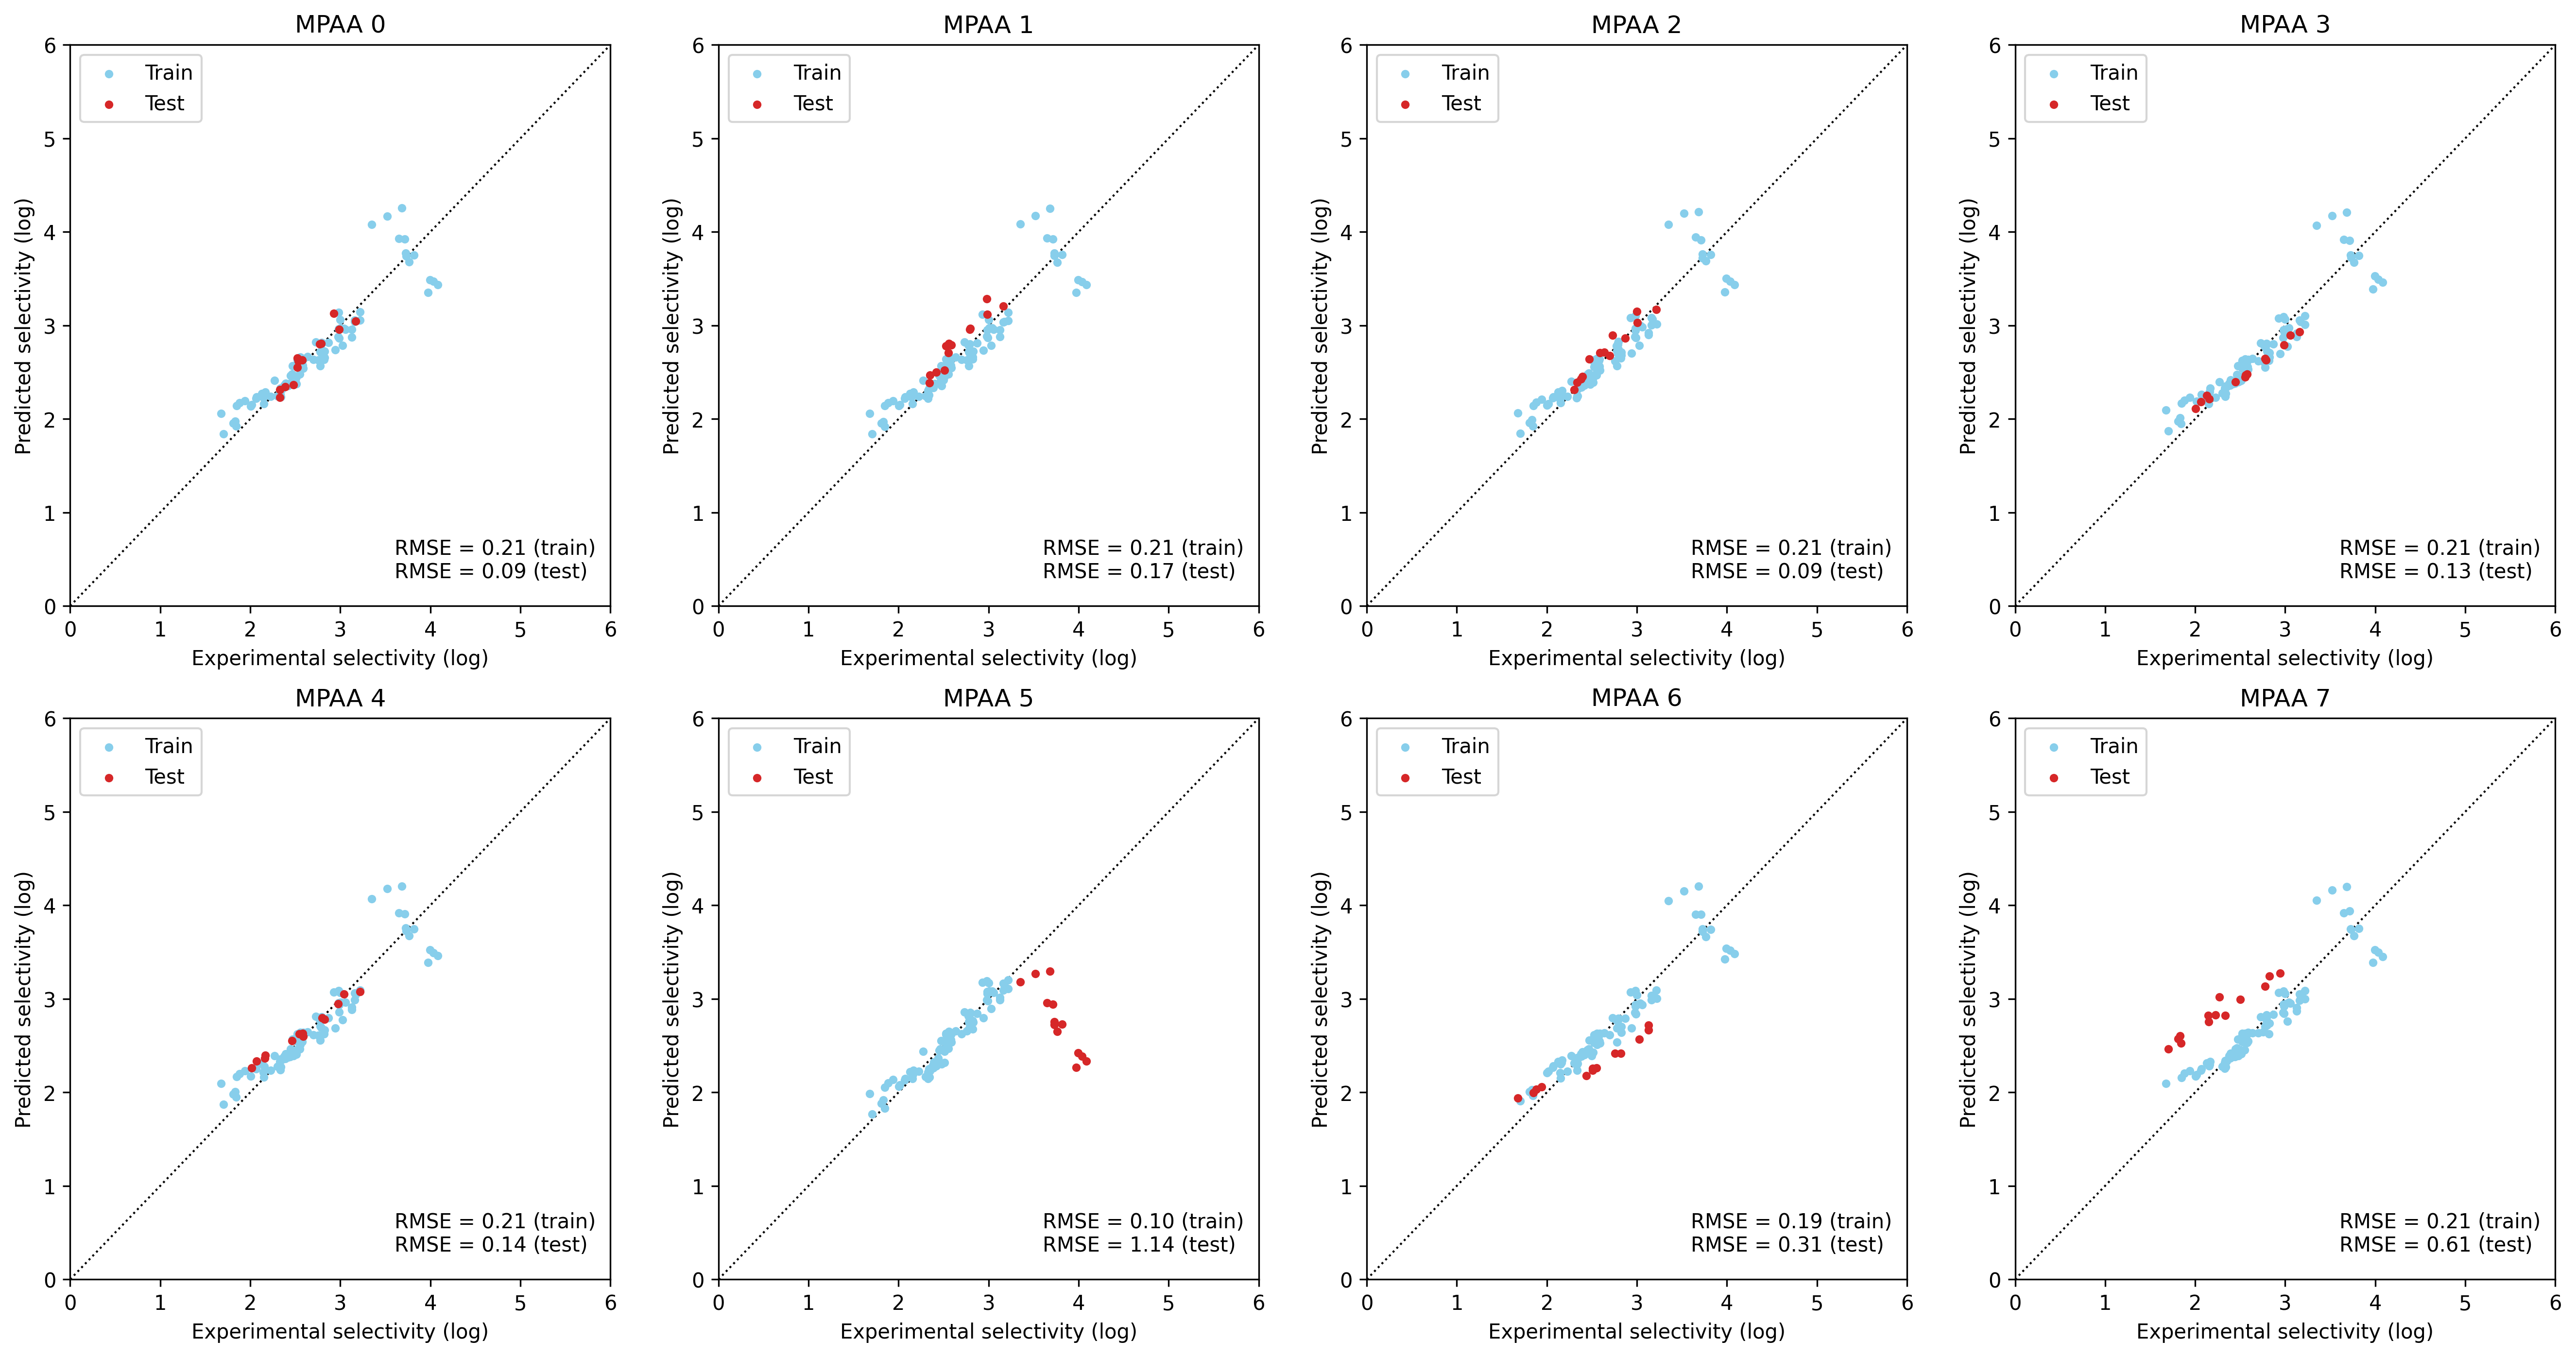

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11), dpi=300)

for group_test in groups_test:
    df_train_val_min_ = df_train_val_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_ = df_test_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_train_val_min_rmse_ = df_train_val_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_rmse_ = df_test_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    
    if group_test == 19:
        group_test = 6
    elif group_test == 20:
        group_test = 7
    
    div, mod = divmod(group_test, 4)
    
    axes[div, mod].plot(
        [0, 100],
        [0, 100],
        c="black",
        linestyle="dotted",
        lw=1,
        zorder=0
    )
    axes[div, mod].scatter(
        df_train_val_min_[column_target],
        df_train_val_min_[column_pred],
        c="skyblue",
        s=10,
        label="Train",
        zorder=1
    )
    axes[div, mod].scatter(
        df_test_min_[column_target],
        df_test_min_[column_pred],
        c="tab:red",
        s=10,
        label="Test",
        zorder=2
    )
    
    axes[div, mod].set_title(f"MPAA {group_test}")
    axes[div, mod].set_xlabel("Experimental selectivity (log)")
    axes[div, mod].set_ylabel("Predicted selectivity (log)")
    axes[div, mod].set_xlim(0, 6)
    axes[div, mod].set_ylim(0, 6)
    
    axes[div, mod].legend()
    axes[div, mod].text(
        0.60, 0.05,
        f"RMSE = {df_train_val_min_rmse_[f'{column_target}_rmse'][0]:1.2f} (train)\n"
        f"RMSE = {df_test_min_rmse_[f'{column_target}_rmse'][0]:1.2f} (test)",
        transform=axes[div, mod].transAxes
    )
    
plt.savefig(
    f"{file_write}_scatter_each.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()